## Model Outline

I am aiming to build a model which yields the observed treatment effect as a product of commuters' and criminals' optimal decisions:

- Train riders decide whether to travel from the station to their home on [0,1] by foot (and leave themselves vulnerable to criminals) or some other risk free outside option, determined by how far their destination is from the station (specified by some exogenous distribution), and the density of criminals up to that point
- Criminals simultaneously decide whether to commit a crime at any point on [0,1], and if so, where to locate themselves on [0,1], subject to a location cost associated with being further from home, where home is determined by some distribution over criminals, and expected reward determined by the density of pedestrians.

I want to calibrate this model to fit the observed treatment effect profile on [0,1], and the parameter of interest is the parameter determining the cost of being far from home (i.e. spatial frictions).

Specifically, think of commuters as having a destination $d \in [0,1]$ drawn randomly from a distribution with pdf $f(d)$. They walk home if the expected costs of victimization is below their outside option cost, $v(d)$, increasing with $d$. If they walk, they're exposed to criminals on $[0,d]$.

Let $c(x)$ be the density of criminals at location $x$. The commuter walks if $\int^d_0 \lambda c(x) dx \leq v(d)$.

The pedestrian density at $x$ is then the mass of pedestrians with destinations beyond $x$: $p(x) = \int^1_x 1(\int^d_0 \lambda c(s)ds \leq v(d))) f(d) dd$

Criminals are assumed to have a home location $h$ drawn from a distribution with pdf $g(h)$. A criminal choosing to locate at $x$ when their home is $h$ gets a payoff of $\pi(x,h) = \alpha p(x) - k(|x-h|)$, where $k$ quantifies the disutility to being far from home (spatial friction). A criminal participates if $\max_x \pi(x,h) \geq 0$, and gets the argmax.

The criminal density is then $c(x) = M \int^1_0 1(x^*(h) = x) \cdot 1(\pi(x^*(h), h) \geq 0) g(h) dh$

An equilibrium here is then densities $p^*(x), c^*(x)$ such that each are consistent with optimal decisions given the other one. This is a fixed point problem with strategic complementarities.

## Imports and Setup

In [29]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize

# Set random seed for reproducibility
np.random.seed(42)

# Global plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Economic Model Class

This class handles the discretization and the simultaneous game between commuters and criminals.

In [16]:
class SpatialCrimeModel:
    def __init__(self, params, dist_commuters, dist_criminals, N=100):
        """
        Initialize the model.
        
        Args:
            params (dict): Dictionary of parameters:
                           - tau: Spatial friction (cost of distance for criminals)
                           - alpha: Value of loot / encounter rate
                           - gamma: Danger aversion for commuters
                           - u_bar: Outside option cost for commuters
                           - M: Total mass of commuters
                           - K: Total mass of criminals
                           - eta: Logit noise parameter for criminal choice (smoothness)
            dist_commuters (func): PDF of commuter home locations f(z)
            dist_criminals (func): PDF of criminal home locations g(y)
            N (int): Number of spatial bins on [0,1]
        """
        self.p = params
        self.N = N
        self.dx = 1.0 / N
        self.x_grid = np.linspace(0, 1, N) # The locations [0, 1]
        
        # Discretize distributions
        # Normalize to ensure they sum to 1 (probability mass)
        self.f_z = dist_commuters(self.x_grid)
        self.f_z = self.f_z / np.sum(self.f_z)
        
        self.g_y = dist_criminals(self.x_grid)
        self.g_y = self.g_y / np.sum(self.g_y)

    def solve_commuters(self, crime_density):
        """
        Commuters decide to walk or take outside option.
        Walk if gamma * Cumulative_Crime < u_bar.
        """
        # 1. Calculate Cumulative Risk at every point z
        # Risk is integral of crime density from station (0) to destination (z)
        cum_risk = np.cumsum(crime_density) * self.p['gamma']
        
        # 2. Find cutoff z* (the furthest point people are willing to walk to)
        # We find the first index where risk > u_bar
        safe_indices = np.where(cum_risk <= self.p['u_bar'])[0]
        
        if len(safe_indices) == 0:
            z_star_idx = 0
        elif len(safe_indices) == self.N:
            z_star_idx = self.N - 1
        else:
            z_star_idx = safe_indices[-1]
            
        # 3. Calculate Walker Density w(x)
        # w(x) = Sum of commuters with destinations z >= x, but z <= z_star
        walker_density = np.zeros(self.N)
        
        # Total mass of walkers per bin, capped at z_star
        effective_commuters = self.f_z.copy()
        if z_star_idx < self.N - 1:
            effective_commuters[z_star_idx+1:] = 0 # No one walks past z_star
            
        # Cumulative sum from right to left (reverse cumsum)
        # Because if I am at x=0.2, I see walkers going to 0.3, 0.4, ...
        walker_density = np.cumsum(effective_commuters[::-1])[::-1]
        
        # Scale by Total Mass M
        return walker_density * self.p['M'], z_star_idx

    def solve_criminals(self, walker_density):
        """
        Criminals at y choose location x to maximize: alpha * w(x) - tau * |x-y|
        modeled as a Logit choice.
        Includes extensive margin (opt-out if expected utility is too low).
        """
        # Create a matrix of Payoffs V[y_idx, x_idx]
        # Rows: Criminal Home (y), Cols: Crime Location (x)
        
        # 1. Revenue (Columns are locations x)
        revenue = self.p['alpha'] * walker_density
        revenue_matrix = np.tile(revenue, (self.N, 1))
        
        # 2. Cost (Rows are homes y, Cols are locations x)
        y_col = self.x_grid.reshape(-1, 1)
        x_row = self.x_grid.reshape(1, -1)
        dist_matrix = np.abs(x_row - y_col)
        cost_matrix = self.p['tau'] * dist_matrix
        
        # 3. Net Utility
        V = revenue_matrix - cost_matrix
        
        # 4. Logit Probabilities P(x|y)
        # We subtract max(V) for numerical stability (avoids overflow in exp)
        V_stable = V - np.max(V, axis=1, keepdims=True)
        exp_V = np.exp(self.p['eta'] * V_stable)
        
        # Denominator includes outside option (utility 0). 
        # Note: exp(0 - max_V) needs to be added to denom if we want outside option 
        # OR we just normalize across spatial choices if we assume they MUST commit crime.
        # Assuming outside option u=0 exists:
        sum_exp_V = np.sum(exp_V, axis=1, keepdims=True) + np.exp(0 - np.max(V, axis=1, keepdims=True))
        
        probs = exp_V / sum_exp_V # Shape (N, N)
        
        # 5. Aggregate Crime Density
        # We need to broadcast the mass of criminals at y (N, 1) across the probabilities (N, N)
        # criminal_mass_at_y shape: (N,) -> (N, 1) for broadcasting
        mass_y = (self.p['K'] * self.g_y).reshape(-1, 1)
        
        # Amount of crime from y at location x
        crime_from_y_at_x = mass_y * probs 
        
        # Total crime at x (Sum over all home locations y)
        crime_density = np.sum(crime_from_y_at_x, axis=0)
        
        return crime_density

    def solve_equilibrium(self, tol=1e-4, max_iter=100, damp=0.5):
        """
        Iterates between commuters and criminals until convergence.
        """
        # Initial Guess: Uniform crime
        crime_density = np.ones(self.N) * (self.p['K'] / self.N)
        
        for i in range(max_iter):
            old_crime = crime_density.copy()
            
            # Step 1: Commuters react to crime
            walker_density, z_star = self.solve_commuters(crime_density)
            
            # Step 2: Criminals react to walkers
            new_crime_dist = self.solve_criminals(walker_density)
            
            # Dampening to prevent oscillation
            crime_density = damp * new_crime_dist + (1 - damp) * old_crime
            
            # Check convergence
            diff = np.linalg.norm(crime_density - old_crime)
            if diff < tol:
                print(f"Converged in {i} iterations. Diff: {diff:.6f}")
                return walker_density, crime_density, z_star
                
        print("Warning: Max iterations reached without strict convergence.")
        return walker_density, crime_density, z_star

## Defining distributions and parameters

In [25]:
# 1. Commuter Destination Distribution f(z)
# Assumption: Linearly decreasing (most people live near station)
def dist_commuters_func(x):
    return 2 - 2*x  # Simple linear decay

# 2. Criminal Home Distribution g(y)
# Assumption: Criminals live uniformly on the interval
def dist_criminals_func(x):
    return 1    # uniform distribution
    # return 1 + x    # Linearly increasing

# Baseline Parameters
params_pre = {
    'tau': 0.1,      # SPATIAL FRICTION (Parameter of Interest)
    'alpha': 0.05,   # Incentive to commit crime
    'gamma': 0.1,    # Fear of crime
    'u_bar': 2.0,    # Cost of taking taxi/bus
    'M': 1000,       # Mass of commuters (Baseline)
    'K': 200,        # Mass of criminals
    'eta': 5.0       # Logit smoothness (Rationality param)
}

## Running the simmulation

In [26]:
# --- PRE PERIOD ---
model_pre = SpatialCrimeModel(params_pre, dist_commuters_func, dist_criminals_func)
w_pre, c_pre, z_pre = model_pre.solve_equilibrium()

# --- POST PERIOD ---
# Shock: More commuters due to extended hours
params_post = params_pre.copy()
params_post['M'] = 1400  # 40% increase in potential traffic

model_post = SpatialCrimeModel(params_post, dist_commuters_func, dist_criminals_func)
w_post, c_post, z_post = model_post.solve_equilibrium()

# --- CALCULATE TREATMENT EFFECT ---
# The difference in crime density
te_profile = c_post - c_pre

Converged in 23 iterations. Diff: 0.000100
Converged in 26 iterations. Diff: 0.000070


In [23]:
print(f"c_pre shape: {c_pre.shape}")
print(f"c_post shape: {c_post.shape}")
print(f"w_pre shape: {w_pre.shape}")
print(f"w_post shape: {w_post.shape}")

c_pre shape: (100,)
c_post shape: (100,)
w_pre shape: (100,)
w_post shape: (100,)


## Visualisation

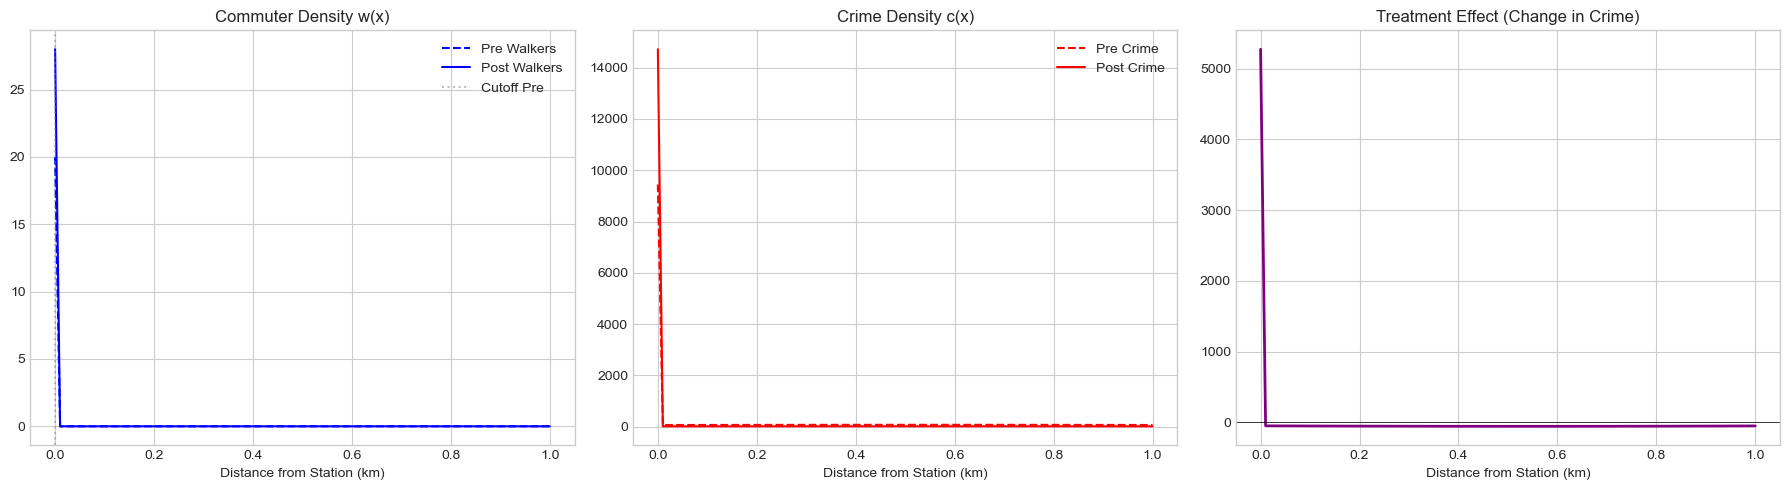

In [27]:
x = model_pre.x_grid

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Walkers
ax1.plot(x, w_pre, label='Pre Walkers', color='blue', linestyle='--')
ax1.plot(x, w_post, label='Post Walkers', color='blue')
ax1.axvline(x[z_pre], color='gray', alpha=0.5, linestyle=':', label='Cutoff Pre')
ax1.set_title("Commuter Density w(x)")
ax1.set_xlabel("Distance from Station (km)")
ax1.legend()

# Plot 2: Crime
ax2.plot(x, c_pre, label='Pre Crime', color='red', linestyle='--')
ax2.plot(x, c_post, label='Post Crime', color='red')
ax2.set_title("Crime Density c(x)")
ax2.set_xlabel("Distance from Station (km)")
ax2.legend()

# Plot 3: Treatment Effect (The target for calibration)
ax3.plot(x, te_profile, color='purple', lw=2)
ax3.set_title("Treatment Effect (Change in Crime)")
ax3.set_xlabel("Distance from Station (km)")
ax3.axhline(0, color='black', lw=0.5)

plt.tight_layout()
plt.show()

## Calibration

In [ ]:
def calibration_objective(tau_guess, observed_te_data, params_base, dist_c, dist_k):
    """
    Objective function to minimize.
    tau_guess: The value of tau the optimizer is testing
    observed_te_data: Your non-parametric estimates (vector of length N)
    """
    
    # 1. Update parameters with guess
    p_pre = params_base.copy()
    p_pre['tau'] = tau_guess
    
    p_post = params_base.copy()
    p_post['tau'] = tau_guess
    p_post['M'] = params_base['M'] * 1.4 # Apply the known shock size
    
    # 2. Solve Pre
    m_pre = SpatialCrimeModel(p_pre, dist_c, dist_k)
    _, c_pre_sim, _ = m_pre.solve_equilibrium()
    
    # 3. Solve Post
    m_post = SpatialCrimeModel(p_post, dist_c, dist_k)
    _, c_post_sim, _ = m_post.solve_equilibrium()
    
    # 4. Calculate Model Treatment Effect
    te_model = c_post_sim - c_pre_sim
    
    # 5. Calculate Loss (Sum of Squared Errors)
    # Assuming observed_te_data is on the same grid or interpolated to it
    sse = np.sum((te_model - observed_te_data)**2)
    
    return sse

# Example Usage (Commented out):
# from scipy.optimize import minimize_scalar
# 
# res = minimize_scalar(
#     calibration_objective, 
#     args=(my_real_data, params_pre, dist_commuters_func, dist_criminals_func),
#     bounds=(0.1, 10.0),
#     method='bounded'
# )
# print(f"Estimated Tau: {res.x}")